In [18]:
# PyTorch ana kütüphanesini içe aktarır - tensor işlemleri ve derin öğrenme için
import torch

# PyTorch'un sinir ağı modülünü içe aktarır - katmanlar, aktivasyon fonksiyonları, kayıp fonksiyonları
import torch.nn as nn

# Stokastik Gradyan İnişi optimizasyonu için
from torch.optim import SGD

# PyTorch veri yükleme yardımcıları - Dataset ve DataLoader sınıfları
from torch.utils.data import Dataset, DataLoader

# Sayısal hesaplamalar ve dizi işlemleri için NumPy kütüphanesi
import numpy as np

# Grafik ve görselleştirme için matplotlib kütüphanesi
import matplotlib.pyplot as plt

# Eğitim/test verisi bölme fonksiyonu
from sklearn.model_selection import train_test_split

# Model performans değerlendirme metrikleri
from sklearn.metrics import accuracy_score

# MNIST veri setini okumak için özel kütüphane
import idx2numpy

## PyTorch Veri İşleme Mimarisi ve Dataset/DataLoader Ekosistemi

### PyTorch'un Veri Yükleme Felsefesi

PyTorch'un veri yükleme yaklaşımı, **composability** (birleştirilebilirlik) ve **efficiency** (verimlilik) prensipleri üzerine kuruludur. Bu sistem, büyük ölçekli makine öğrenmesi projelerinde karşılaşılan temel zorlukları çözmek için tasarlanmıştır:

#### 1. **Bellek Yönetimi Problemleri**
```
Geleneksel Yaklaşım (Naif):
├── Tüm veriyi RAM'e yükle
├── Bellek tükenmesi (OOM - Out of Memory)
└── 64GB+ RAM gereksinimi

PyTorch Dataset Yaklaşımı:
├── Lazy loading (ihtiyaç halinde yükleme)
├── Streaming data access
├── Memory-mapped files desteği
└── 8GB RAM ile terabayt veriler işlenebilir
```

#### 2. **I/O Bottleneck Çözümü**
```
Problem: Disk okuma hızı << GPU hesaplama hızı
├── GPU beklemede (underutilization)
├── Training time'ın %70'i I/O wait
└── Pahalı GPU kaynaklarının verimsiz kullanımı

DataLoader Çözümü:
├── Multi-process data loading
├── Prefetching (önceden yükleme)
├── Background data preparation
└── GPU utilization %95+
```

#### 3. **Veri Transformasyon Pipeline'ı**
```
Raw Data → Augmentation → Normalization → Tensor → GPU
    ↑           ↑            ↑           ↑       ↑
    Disk     CPU-intensive  Vectorized  Memory  CUDA
             ops            ops         Transfer
```

In [19]:
# MNIST veri seti dosya yolu
MNIST_DIR = "mnist/"

# MNIST eğitim görüntülerini oku (60000 adet 28x28 piksel görüntü)
# idx2numpy.convert_from_file(): IDX formatındaki dosyayı NumPy dizisine dönüştürür
X_mnist = idx2numpy.convert_from_file(MNIST_DIR + "train-images-idx3-ubyte")

# Görüntüleri düzleştir ve normalize et: (60000, 28, 28) -> (60000, 784) ve [0,255] -> [0,1]
# reshape(60000, -1): -1 otomatik boyut hesaplama (28*28=784)
# /255.0: Piksel değerlerini 0-1 aralığına normalize et
X_mnist = X_mnist.reshape(60000, -1) / 255.0

# MNIST eğitim etiketlerini oku (0-9 arası rakam etiketleri)
y_mnist = idx2numpy.convert_from_file(MNIST_DIR + "train-labels-idx1-ubyte")

# İlk 5 etiketin değerlerini kontrol et
print(y_mnist[:5])

# Veri setindeki benzersiz etiketleri kontrol et (0-9 arası olmalı)
print(np.unique(y_mnist))

[5 0 4 1 9]
[0 1 2 3 4 5 6 7 8 9]


## Douglas Adams ve 42 Sayısının Önemi

Douglas Adams'ın "Otostopçunun Galaksi Rehberi" adlı eserinde, 42 sayısı "Yaşam, Evren ve Her Şeyin Anlamı"nın cevabı olarak sunulur. Bu cevap, 7.5 milyon yıl boyunca Deep Thought adlı devasa bir süper bilgisayar tarafından hesaplanmıştır. Ne yazık ki, sorunun ne olduğunu kimse bilmemektedir.

### `torch.utils.data.Dataset` Sınıfının Derinlemesine Mimarisi

#### Abstract Base Class (ABC) Tasarım Deseni

PyTorch'un `Dataset` sınıfı, **Template Method** tasarım desenini kullanır:

```python
# PyTorch kaynak kodu (basitleştirilmiş):
class Dataset:
    def __getitem__(self, index):
        raise NotImplementedError
    
    def __len__(self):
        raise NotImplementedError
    
    # Template methods (somut uygulamalar):
    def __iter__(self):
        for i in range(len(self)):
            yield self[i]
    
    def __add__(self, other):
        return ConcatDataset([self, other])
```

#### Protokol Arayüzü (Protocol Interface)

Dataset sınıfı, Python'un **duck typing** yaklaşımını benimser:

```python
# Minimum viable dataset:
class MinimalDataset:
    def __init__(self, data): self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

# PyTorch tarafından otomatik olarak desteklenir:
dataloader = DataLoader(MinimalDataset([1,2,3,4]))
```

#### Bellek Düzeni ve Cache Verimliliği

**Cache-Dostu Veri Erişim Desenleri:**
```python
# Kötü: Rastgele erişim deseni
for _ in range(epochs):
    for i in random.shuffle(range(len(dataset))):
        item = dataset[i]  # Cache miss olasılığı yüksek

# İyi: Epoch seviyesinde karıştırma ile sıralı erişim
for _ in range(epochs):
    indices = list(range(len(dataset)))
    random.shuffle(indices)  # Epoch başına bir kez karıştır
    for i in indices:
        item = dataset[i]  # Daha iyi cache kullanımı
```

#### Thread Safety ve Multiprocessing

**Dataset Thread Safety Gereksinimleri:**
```python
# Thread-safe dataset örneği:
class ThreadSafeDataset(Dataset):
    def __init__(self, data):
        self._data = data
        self._lock = threading.Lock()
    
    def __getitem__(self, index):
        with self._lock:  # Kritik bölüm
            return self._data[index].copy()  # Güvenlik için deep copy
```

#### Lazy Loading Uygulama Desenleri

**Memory-Mapped Dosyalar:**
```python
class MemoryMappedDataset(Dataset):
    def __init__(self, file_path):
        self.mmap_file = np.memmap(file_path, dtype='float32', mode='r')
        self.shape = self.mmap_file.shape
    
    def __getitem__(self, index):
        # O(1) erişim, minimal bellek kullanımı
        return torch.from_numpy(self.mmap_file[index])
```

**HDF5 Backend:**
```python
import h5py

class HDF5Dataset(Dataset):
    def __init__(self, h5_path):
        self.h5_file = h5py.File(h5_path, 'r')
        self.data = self.h5_file['data']
        
    def __getitem__(self, index):
        # Sıkıştırma + chunking avantajları
        return torch.tensor(self.data[index])
```

In [20]:
# MNIST veri setini eğitim ve test setlerine böl
# - test_size=0.2: Verinin %20'si test için ayrılır (%80 eğitim)
# - random_state=42: Aynı bölünmeyi her seferinde elde etmek için seed
X_train, X_test, y_train, y_test = train_test_split(X_mnist, y_mnist, test_size=0.2, random_state=42)  

# NumPy dizilerini PyTorch tensörlerine dönüştür
# from_numpy(): NumPy dizisini PyTorch tensörüne dönüştürür (hafıza paylaşımlı)
# astype(np.float32): Veri tipini 32-bit float'a dönüştür (GPU uyumluluğu için)
x = torch.from_numpy(X_train.astype(np.float32))

# Etiketleri int64 (long) tipine dönüştür (CrossEntropyLoss için gerekli)
y = torch.from_numpy(y_train.astype(np.int64))

# Tensör boyutlarını kontrol et
print(x.shape)  # (48000, 784) - 48000 eğitim örneği, 784 özellik
print(y.shape)  # (48000,) - 48000 etiket

torch.Size([48000, 784])
torch.Size([48000])


## Torch Dataset'ten Türeyen Kendi Sınıfımızı Oluşturma

### `torch.utils.data.DataLoader` İçsel Mimarisi ve Optimizasyon Teknikleri

#### Çok İşlemcili Veri Yükleme Mimarisi

**Process Pool Yönetimi:**
```python
# DataLoader internal architecture:
class DataLoader:
    def __init__(self, dataset, batch_size=1, num_workers=0, 
                 pin_memory=False, prefetch_factor=2):
        
        if num_workers > 0:
            # Ana süreç
            self.master_pid = os.getpid()
            
            # İşçi süreçler
            self.worker_processes = []
            for i in range(num_workers):
                worker = mp.Process(target=self._worker_loop, args=(i,))
                worker.start()
                self.worker_processes.append(worker)
            
            # Süreçler arası iletişim
            self.index_queue = mp.Queue()      # Ana → İşçiler
            self.data_queue = mp.Queue()       # İşçiler → Ana
```

**İşçi Süreç Yaşam Döngüsü:**
```python
def _worker_loop(self, worker_id):
    # İşçi süreç ana döngüsü
    dataset_copy = copy.deepcopy(self.dataset)  # Her işçi kendi kopyasını alır
    
    while True:
        try:
            batch_indices = self.index_queue.get(timeout=1.0)
            if batch_indices is None:  # Kapatma sinyali
                break
                
            # İşçi süreçte batch birleştirme
            batch_data = []
            for idx in batch_indices:
                sample = dataset_copy[idx]
                batch_data.append(sample)
            
            # Collate fonksiyonu uygulama
            batch = self.collate_fn(batch_data)
            
            # Anaya geri gönder
            self.data_queue.put((worker_id, batch))
            
        except queue.Empty:
            continue  # Timeout, kapatma kontrolü yap
```

#### Batching ve Collation Stratejileri

**Varsayılan Collate Fonksiyonu Analizi:**
```python
def default_collate(batch):
    """
    PyTorch'un batching mantığına derin bakış
    """
    elem = batch[0]
    elem_type = type(elem)
    
    if isinstance(elem, torch.Tensor):
        # Tensor yığınlama optimizasyonu
        out = None
        if torch.utils.data.get_worker_info() is not None:
            # İşçi süreç: önceden depolama ayır
            numel = sum([x.numel() for x in batch])
            storage = elem.storage()._new_shared(numel)
            out = elem.new(storage)
        
        return torch.stack(batch, 0, out=out)
    
    elif isinstance(elem, np.ndarray):
        # NumPy → Tensor dönüştürme
        if elem.dtype == np.str_ or elem.dtype.kind == 'U':
            # String diziler: otomatik dönüştürme yok
            return batch
        else:
            # Sayısal diziler: tensörlere dönüştür
            return default_collate([torch.from_numpy(b) for b in batch])
    
    elif isinstance(elem, (list, tuple)):
        # İç içe yapılar için rekürsif collation
        transposed = list(zip(*batch))
        return [default_collate(samples) for samples in transposed]
```

**Özel Collate Fonksiyonları:**
```python
def variable_length_collate(batch):
    """
    Değişken uzunluklu dizileri işle (örn. metin, zaman serisi)
    """
    # Uzunluğa göre sırala (verimli paketleme için)
    batch.sort(key=lambda x: len(x[0]), reverse=True)
    
    sequences, labels = zip(*batch)
    lengths = [len(seq) for seq in sequences]
    
    # Dizileri batch'teki maksimum uzunluğa kadar doldur
    max_len = lengths[0]
    padded_seqs = torch.zeros(len(sequences), max_len, sequences[0].size(-1))
    
    for i, seq in enumerate(sequences):
        padded_seqs[i, :len(seq)] = seq
    
    return padded_seqs, torch.tensor(labels), torch.tensor(lengths)
```

#### Pin Memory ve GPU Transfer Optimizasyonu

**Pin Memory Mekanizması:**
```python
class PinnedMemoryDataset:
    """
    Daha hızlı CPU→GPU transferleri için CUDA pinned memory
    """
    def __init__(self, dataset):
        self.dataset = dataset
        
    def __getitem__(self, index):
        sample = self.dataset[index]
        
        if isinstance(sample, torch.Tensor):
            # Tensörü bellekte sabitle
            return sample.pin_memory()
        else:
            return sample

# Performans karşılaştırması:
# Normal transfer: ~1.5 GB/s (PCIe bant genişliği sınırlı)
# Pinned memory:   ~8-12 GB/s (tam PCIe kullanımı)
```

**Asenkron GPU Transfer:**
```python
class AsyncGPULoader:
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        self.stream = torch.cuda.Stream()
    
    def __iter__(self):
        iterator = iter(self.dataloader)
        
        # İlk batch'i önceden yükle
        with torch.cuda.stream(self.stream):
            next_batch = next(iterator).to(self.device, non_blocking=True)
        
        for batch in iterator:
            # Önceki transferi bekle
            torch.cuda.current_stream().wait_stream(self.stream)
            current_batch = next_batch
            
            # Sonraki transferi asenkron başlat
            with torch.cuda.stream(self.stream):
                next_batch = batch.to(self.device, non_blocking=True)
            
            yield current_batch
        
        # Son batch
        torch.cuda.current_stream().wait_stream(self.stream)
        yield next_batch
```

#### Bellek Yönetimi ve Garbage Collection

**DataLoader Bellek Profilleme:**
```python
import tracemalloc

def profile_dataloader_memory(dataloader):
    tracemalloc.start()
    
    peak_memory = 0
    for i, batch in enumerate(dataloader):
        current, peak = tracemalloc.get_traced_memory()
        peak_memory = max(peak_memory, peak)
        
        if i % 100 == 0:
            print(f"Batch {i}: Mevcut={current/1024/1024:.1f}MB, "
                  f"Pik={peak/1024/1024:.1f}MB")
        
        # Periyodik olarak garbage collection zorla
        if i % 1000 == 0:
            import gc
            gc.collect()
    
    tracemalloc.stop()
    return peak_memory
```

In [21]:
# PyTorch Dataset sınıfından türetilen özel MNIST veri seti sınıfı
class MnistDataset(Dataset):
    def __init__(self, X, y):
        # Veri seti başlangıç fonksiyonu - veri yükleme ve ön işleme
        
        # NumPy dizilerini PyTorch tensörlerine dönüştür
        # astype(np.float32): Özellikler için 32-bit float veri tipi
        self.x = torch.from_numpy(X.astype(np.float32))
        
        # astype(np.int64): Etiketler için 64-bit integer veri tipi (sınıflandırma için)
        self.y = torch.from_numpy(y.astype(np.int64))

    def __getitem__(self, index):
        # Belirli bir indeksteki veri örneğini döndür
        # Bu metod, dataset[index] sözdiziminin çalışmasını sağlar
        # Dönen değer: (özellik_vektörü, etiket) çifti
        return self.x[index], self.y[index]

    def __len__(self):
        # Veri setindeki toplam örnek sayısını döndür
        # Bu metod, len(dataset) sözdiziminin çalışmasını sağlar
        # shape[0]: İlk boyut (örnek sayısı)
        return self.x.shape[0]

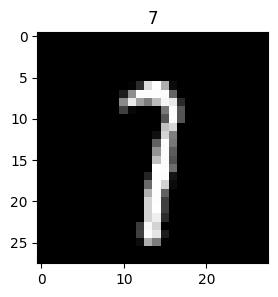

In [22]:
# MnistDataset sınıfından bir örnek oluştur
dataset = MnistDataset(X_train, y_train)

# 42 numaralı indeksteki veri örneğini al
# Douglas Adams'ın "Hitchhiker's Guide to the Galaxy"sinde yaşam, evren ve her şeyin anlamının cevabı
first_x, first_y = dataset[42]

# Seçilen örneği görselleştir
plt.figure(figsize=(3, 3))

# Etiket değerini başlık olarak göster
# .item(): Tensör skalarını Python sayısına dönüştürür
plt.title(first_y.item())

# 784 boyutlu vektörü 28x28 görüntüye dönüştür ve göster
# reshape(28, 28): Düzleştirilmiş vektörü orijinal 2D forma döndür
# cmap="gray": Gri tonlama renk haritası
plt.imshow(first_x.reshape(28, 28), cmap="gray")

# Grafiği göster
plt.show()

### `nn.Module` Derin Mimarisi ve PyTorch Autograd Sistemi

#### nn.Module'ün İçsel Yapısı ve Metaclass Sihri

**Parameter Registration Mekanizması:**
```python
class ModuleMetaclass(type):
    """
    PyTorch'un nn.Module için kullandığı metaclass
    """
    def __call__(cls, *args, **kwargs):
        instance = super().__call__(*args, **kwargs)
        
        # Otomatik parametre keşfi
        for name, value in instance.__dict__.items():
            if isinstance(value, nn.Parameter):
                instance._parameters[name] = value
            elif isinstance(value, nn.Module):
                instance._modules[name] = value
        
        return instance

class Module(metaclass=ModuleMetaclass):
    def __init__(self):
        self._parameters = OrderedDict()
        self._modules = OrderedDict()
        self._buffers = OrderedDict()
        self.training = True
```

**Parameter vs Buffer vs Module:**
```python
class DetailedModule(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Parametreler: öğrenilebilir, requires_grad=True
        self.weight = nn.Parameter(torch.randn(10, 5))
        
        # Bufferlar: öğrenilemeyen, ama state_dict'in parçası
        self.register_buffer('running_mean', torch.zeros(10))
        
        # Modüller: iç içe nn.Module örnekleri
        self.linear = nn.Linear(5, 1)
    
    def state_dict_analysis(self):
        """
        Parametreler: {'weight': tensor, 'linear.weight': tensor, 'linear.bias': tensor}
        Bufferlar: {'running_mean': tensor}
        Tam state_dict: parametreler + bufferlar
        """
        return {
            'parameters': dict(self.named_parameters()),
            'buffers': dict(self.named_buffers()),
            'modules': dict(self.named_modules())
        }
```

#### Autograd Sistemi: Hesaplama Grafiği İnşası

**Dinamik Hesaplama Grafiği:**
```python
class AutogradAnalysis:
    """
    PyTorch'un otomatik türev alma sisteminin analizi
    """
    
    @staticmethod
    def trace_computation_graph():
        # Gradyan izlemeli girdi
        x = torch.randn(2, 2, requires_grad=True)
        
        # İleri işlemler grafik düğümleri oluşturur
        y = x + 2        # AddBackward0
        z = y * y * 3    # MulBackward0 -> MulBackward0
        out = z.mean()   # MeanBackward0
        
        # Hesaplama grafiği yapısı:
        """
        x (yaprak, requires_grad=True)
        ↓
        AddBackward0 (y = x + 2)
        ↓
        MulBackward0 (temp = y * y)
        ↓
        MulBackward0 (z = temp * 3)
        ↓
        MeanBackward0 (out = z.mean())
        """
        
        return out

    @staticmethod
    def analyze_gradient_flow():
        x = torch.randn(3, requires_grad=True)
        
        # Karmaşık hesaplama
        y = x ** 2
        z = y.sum()
        
        # Geri geçiş
        z.backward()
        
        # Gradyan analizi:
        """
        dz/dx = d/dx(sum(x²)) = 2x
        x.grad [2*x[0], 2*x[1], 2*x[2]] içerecek
        """
        
        return x.grad
```

#### Hook Sistemi: Gradyan ve Aktivasyon İzleme

**Forward Hook'lar:**
```python
class ActivationTracker:
    def __init__(self):
        self.activations = {}
    
    def hook_fn(self, module, input, output):
        module_name = module.__class__.__name__
        self.activations[module_name] = {
            'input_shape': input[0].shape,
            'output_shape': output.shape,
            'output_mean': output.mean().item(),
            'output_std': output.std().item()
        }
    
    def register_hooks(self, model):
        for name, module in model.named_modules():
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                module.register_forward_hook(self.hook_fn)

# Kullanım:
tracker = ActivationTracker()
tracker.register_hooks(model)
output = model(input_tensor)
print(tracker.activations)
```

**Backward Hook'lar:**
```python
class GradientAnalyzer:
    def __init__(self):
        self.gradients = {}
    
    def backward_hook(self, module, grad_input, grad_output):
        module_name = module.__class__.__name__
        
        if grad_output[0] is not None:
            self.gradients[module_name] = {
                'grad_output_norm': grad_output[0].norm().item(),
                'grad_input_norm': grad_input[0].norm().item() if grad_input[0] is not None else 0,
                'gradient_ratio': (grad_output[0].norm() / (grad_input[0].norm() + 1e-8)).item()
            }
    
    def register_hooks(self, model):
        for module in model.modules():
            if isinstance(module, (nn.Linear, nn.Conv2d)):
                module.register_backward_hook(self.backward_hook)

# Gradyan patlama/kaybolma tespiti:
analyzer = GradientAnalyzer()
analyzer.register_hooks(model)
loss.backward()
print(analyzer.gradients)
```

#### Modül Durum Yönetimi

**Eğitim vs Değerlendirme Modu:**
```python
class ModeAwareModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 5)
        self.dropout = nn.Dropout(0.5)
        self.batch_norm = nn.BatchNorm1d(5)
    
    def forward(self, x):
        x = self.linear(x)
        
        # Moda bağımlı davranış:
        if self.training:
            # Eğitim modu:
            # - Dropout: elementleri rastgele sıfırla
            # - BatchNorm: batch istatistiklerini kullan
            x = self.dropout(x)
            x = self.batch_norm(x)
        else:
            # Değerlendirme modu:
            # - Dropout: no-op (kimlik)
            # - BatchNorm: saklanan running istatistikleri kullan
            x = self.dropout(x)  # Dropout uygulanmaz
            x = self.batch_norm(x)  # Saklanan running_mean/var kullanır
        
        return x
    
    def toggle_analysis(self):
        """
        Modlar arası davranış değişikliklerini analiz et
        """
        x = torch.randn(32, 10)
        
        self.train()
        train_output = self(x)
        
        self.eval()
        eval_output = self(x)
        
        return {
            'train_mean': train_output.mean().item(),
            'eval_mean': eval_output.mean().item(),
            'train_std': train_output.std().item(),
            'eval_std': eval_output.std().item(),
            'output_diff': (train_output - eval_output).abs().mean().item()
        }
```

#### Cihaz Yönetimi ve CUDA Optimizasyonu

**Çok-GPU Model Paralelliği:**
```python
class MultiGPUModule(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        # Katmanları GPU'lara böl
        self.layer1 = nn.Linear(input_size, hidden_size).to('cuda:0')
        self.layer2 = nn.Linear(hidden_size, hidden_size).to('cuda:1')
        self.layer3 = nn.Linear(hidden_size, output_size).to('cuda:0')
    
    def forward(self, x):
        # Açık cihaz transferleri
        x = x.to('cuda:0')
        x = F.relu(self.layer1(x))
        
        x = x.to('cuda:1')  # GPU 1'e taşı
        x = F.relu(self.layer2(x))
        
        x = x.to('cuda:0')  # GPU 0'a geri taşı
        x = self.layer3(x)
        
        return x
    
    def memory_analysis(self):
        """
        Cihazlar arası bellek kullanımını analiz et
        """
        return {
            'cuda:0_memory': torch.cuda.memory_allocated(0),
            'cuda:1_memory': torch.cuda.memory_allocated(1),
            'total_params_gpu0': sum(p.numel() for p in self.layer1.parameters()) + 
                               sum(p.numel() for p in self.layer3.parameters()),
            'total_params_gpu1': sum(p.numel() for p in self.layer2.parameters())
        }
```

## Kendi MnistDataset Sınıfımızı Kullanan DataLoader Nesnesi Oluşturma

### Model Eğitim Döngüsü: İleri Seviye Optimizasyon Teknikleri

#### CrossEntropyLoss Derinlemesine Analizi

**Matematiksel Formülasyon ve Sayısal Kararlılık:**
```python
class StableCrossEntropyLoss:
    """
    Sayısal olarak kararlı CrossEntropyLoss uygulaması
    """
    
    @staticmethod
    def manual_cross_entropy(logits, targets):
        """
        İçsel çalışmayı gösteren manuel uygulama
        """
        # Adım 1: Sayısal kararlılık için LogSumExp
        max_logits = torch.max(logits, dim=1, keepdim=True)[0]
        shifted_logits = logits - max_logits
        
        # Adım 2: Log olasılıklarını hesapla
        log_sum_exp = torch.log(torch.sum(torch.exp(shifted_logits), dim=1, keepdim=True))
        log_probs = shifted_logits - log_sum_exp
        
        # Adım 3: Negative log likelihood
        batch_size = logits.size(0)
        loss = -log_probs[range(batch_size), targets]
        
        return loss.mean()
    
    @staticmethod
    def compare_implementations():
        """
        Sayısal kararlılığı karşılaştır
        """
        # Ekstrem logitler (potansiyel overflow)
        logits = torch.tensor([[1000., 1001., 999.]], dtype=torch.float32)
        targets = torch.tensor([1])
        
        # PyTorch uygulaması (kararlı)
        pytorch_loss = F.cross_entropy(logits, targets)
        
        # Naive uygulama (kararsız)
        naive_softmax = F.softmax(logits, dim=1)
        naive_loss = -torch.log(naive_softmax[0, targets[0]])
        
        # Manuel kararlı uygulama
        stable_loss = StableCrossEntropyLoss.manual_cross_entropy(logits, targets)
        
        return {
            'pytorch_loss': pytorch_loss.item(),
            'naive_loss': naive_loss.item(),  # inf veya nan olabilir
            'stable_loss': stable_loss.item()
        }
```

**Label Smoothing ve Regularization:**
```python
class LabelSmoothingCrossEntropy(nn.Module):
    """
    Daha iyi genelleme için label smoothing
    """
    def __init__(self, num_classes, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing
    
    def forward(self, logits, targets):
        """
        Label smoothing uygula:
        y_smooth = (1-ε)y_true + ε/K
        burada ε smoothing faktörü, K sınıf sayısı
        """
        log_probs = F.log_softmax(logits, dim=1)
        
        # Smoothing ile one-hot encoding
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (self.num_classes - 1))
            true_dist.scatter_(1, targets.unsqueeze(1), self.confidence)
        
        # Smooth hedef ve tahmin dağılımı arası KL divergence
        return torch.mean(torch.sum(-true_dist * log_probs, dim=1))
```

#### Gelişmiş SGD: Momentum ve Adaptive Learning

**Momentum'lu SGD Detaylı Analizi:**
```python
class MomentumSGD:
    """
    Momentum'lu SGD'nin manuel uygulaması
    """
    def __init__(self, parameters, lr=0.01, momentum=0.9, weight_decay=0):
        self.parameters = list(parameters)
        self.lr = lr
        self.momentum = momentum
        self.weight_decay = weight_decay
        
        # Momentum bufferlarını başlat
        self.velocity = [torch.zeros_like(p) for p in self.parameters]
    
    def step(self):
        for i, param in enumerate(self.parameters):
            if param.grad is None:
                continue
            
            grad = param.grad.data
            
            # L2 weight decay
            if self.weight_decay != 0:
                grad = grad.add(param.data, alpha=self.weight_decay)
            
            # Momentum güncellemesi
            self.velocity[i] = self.momentum * self.velocity[i] + grad
            
            # Parametre güncellemesi
            param.data = param.data - self.lr * self.velocity[i]
    
    def zero_grad(self):
        for param in self.parameters:
            if param.grad is not None:
                param.grad.zero_()

# Momentum etkisi analizi:
"""
Momentum olmadan:
θₜ₊₁ = θₜ - η∇L(θₜ)
- Dar vadilerde salınım yapabilir
- Platolarда yavaş yakınsama

Momentum ile:
vₜ₊₁ = βvₜ + ∇L(θₜ)
θₜ₊₁ = θₜ - ηvₜ₊₁
- Salınımları yumuşatır
- Tutarlı yönlerde hızlanır
- β=0.9 önceki velocity'nin %90'ını korur
"""
```

#### Batch Size Etkileri: Mini-batch vs Full Batch

**Gradyan Gürültü Analizi:**
```python
class GradientNoiseAnalyzer:
    """
    Batch boyutunun gradyan gürültüsü üzerindeki etkisini analiz et
    """
    
    @staticmethod
    def compute_gradient_variance(model, dataloader, num_samples=100):
        """
        Farklı batch boyutları için gradyan varyansını tahmin et
        """
        gradients = []
        
        for i, (X, y) in enumerate(dataloader):
            if i >= num_samples:
                break
                
            # Bu batch için gradyanı hesapla
            output = model(X)
            loss = F.cross_entropy(output, y)
            
            grad_dict = torch.autograd.grad(loss, model.parameters(), retain_graph=False)
            gradients.append([g.clone() for g in grad_dict])
        
        # Batch'ler arası varyansı hesapla
        variances = []
        for param_idx in range(len(gradients[0])):
            param_grads = torch.stack([g[param_idx] for g in gradients])
            variance = torch.var(param_grads, dim=0).mean().item()
            variances.append(variance)
        
        return variances
    
    @staticmethod
    def generalization_analysis():
        """
        Batch boyutu etkilerinin teorik analizi
        """
        return {
            'small_batch_benefits': [
                'Daha yüksek gradyan gürültüsü → daha iyi exploration',
                'İmplicit regularization etkisi',
                'Daha iyi genelleme (düzere minimalar)',
                'Daha sık parametre güncellemeleri'
            ],
            'large_batch_benefits': [
                'Daha doğru gradyan tahminleri',
                'Daha iyi yakınsama garantileri',
                'Daha verimli GPU kullanımı',
                'Kararlı eğitim dinamikleri'
            ],
            'optimal_strategy': 'Eğitim sırasında progressif batch boyutu artırma'
        }
```

#### Bellek Optimizasyon Teknikleri

**Gradyan Biriktirme:**
```python
class GradientAccumulator:
    """
    Gradyan biriktirme ile büyük batch boyutlarını simüle et
    """
    def __init__(self, model, optimizer, accumulation_steps=4):
        self.model = model
        self.optimizer = optimizer
        self.accumulation_steps = accumulation_steps
        self.current_step = 0
    
    def accumulate_step(self, loss):
        """
        Parametreleri güncellemeden gradyanları biriktir
        """
        # Loss'u biriktirme adımlarına böl
        scaled_loss = loss / self.accumulation_steps
        scaled_loss.backward()
        
        self.current_step += 1
        
        # Biriktirme tamamlandığında parametreleri güncelle
        if self.current_step % self.accumulation_steps == 0:
            self.optimizer.step()
            self.optimizer.zero_grad()
    
    def finalize_epoch(self):
        """
        Epoch sonunda kalan gradyanları işle
        """
        if self.current_step % self.accumulation_steps != 0:
            self.optimizer.step()
            self.optimizer.zero_grad()

# Bellek analizi:
"""
Normal eğitim (batch_size=256):
Bellek = 256 * (forward_activations + backward_gradients)

Gradyan biriktirme (effective_batch_size=256, micro_batch=64):
Bellek = 64 * (forward_activations + backward_gradients)
Etkili batch boyutu = 256 (aynı yakınsama)
Bellek azalması = 4x
"""
```

#### Learning Rate Scheduling

**Cosine Annealing Uygulaması:**
```python
class CosineAnnealingLR:
    """
    Cosine annealing learning rate scheduler
    """
    def __init__(self, optimizer, T_max, eta_min=0):
        self.optimizer = optimizer
        self.T_max = T_max
        self.eta_min = eta_min
        self.base_lrs = [group['lr'] for group in optimizer.param_groups]
        self.current_epoch = 0
    
    def step(self):
        """
        Cosine annealing kullanarak learning rate'i güncelle
        """
        for param_group, base_lr in zip(self.optimizer.param_groups, self.base_lrs):
            # Cosine annealing formülü
            param_group['lr'] = self.eta_min + (base_lr - self.eta_min) * \
                               (1 + math.cos(math.pi * self.current_epoch / self.T_max)) / 2
        
        self.current_epoch += 1
    
    def get_lr_analysis(self):
        """
        Learning rate programını analiz et
        """
        epochs = list(range(self.T_max))
        lrs = []
        
        for epoch in epochs:
            lr = self.eta_min + (self.base_lrs[0] - self.eta_min) * \
                 (1 + math.cos(math.pi * epoch / self.T_max)) / 2
            lrs.append(lr)
        
        return epochs, lrs

# Warm restart stratejisi:
"""
SGDR (Stochastic Gradient Descent with Warm Restarts):
- Learning rate'i periyodik olarak yüksek değere restart et
- Modelin lokal minimumlardan kaçmasını sağlar
- T_max her restart ile artar: T₀, 2*T₀, 4*T₀, ...
"""
```

In [23]:
# Dataset'i kullanarak DataLoader oluştur
# DataLoader: Mini-batch eğitimi, veri karıştırma ve paralel yükleme sağlar
data_loader = DataLoader(
    dataset=dataset,     # Kullanılacak veri seti
    batch_size=4,        # Her batch'te 4 örnek olsun
    shuffle=True         # Her epoch'ta veriyi karıştır (overfitting'i önler)
)

# DataLoader'dan iterator oluştur
# iter(): DataLoader'ı yinelenebilir nesneye dönüştürür
data_iterator = iter(data_loader)

# İlk batch'i al
# next(): Iterator'dan bir sonraki öğeyi (batch'i) getirir
x, y = next(data_iterator)

# Batch boyutlarını kontrol et
print(f"x.shape: {x.shape}, y.shape:{y.shape}")
# x.shape: (4, 784) - 4 örnek, her biri 784 özellikli
# y.shape: (4,) - 4 etiket

x.shape: torch.Size([4, 784]), y.shape:torch.Size([4])


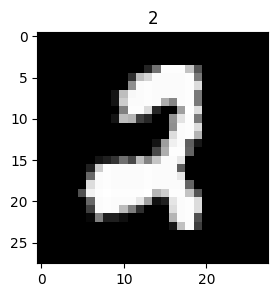

In [24]:
# Batch'teki 4. örneği görselleştir (indeks 3)
plt.figure(figsize=(3, 3))

# y[3]: Batch'teki 4. örneğin etiketini al
# .item(): Tensör skalarını Python sayısına dönüştür
plt.title(y[3].item())

# x[3]: Batch'teki 4. örneğin özellik vektörünü al
# reshape(28, 28): 784 boyutlu vektörü 28x28 görüntüye dönüştür
plt.imshow(x[3].reshape(28, 28), cmap="gray")

# Grafiği göster
plt.show()

## Çok Sınıflı Sınıflandırma Modeli Oluşturma 

**Model Mimarisi:**
1. Giriş katmanı: 784 → 32
2. Sigmoid aktivasyon fonksiyonu
3. Çıkış katmanı: 32 → 10

In [25]:
# Çok sınıflı MNIST sınıflandırması için sinir ağı modeli
class MNistClassifier(nn.Module):
    def __init__(self):
        # Üst sınıfın (nn.Module) __init__ metodunu çağır
        super().__init__()
        
        # Girdi katmanı: 784 nörondan 32 nörona lineer dönüşüm
        # 784: Düzleştirilmiş 28x28 piksel görüntü
        # 32: Gizli katman boyutu (hiperparametre)
        self.input_layer = nn.Linear(784, 32)
        
        # Sigmoid aktivasyon fonksiyonu
        # σ(x) = 1/(1+e^(-x)) - çıkışı 0-1 aralığında sıkıştırır
        self.activation = nn.Sigmoid()
        
        # Çıkış katmanı: 32 nörondan 10 sınıfa lineer dönüşüm
        # 10: MNIST'te 10 farklı rakam sınıfı (0-9)
        self.output_layer = nn.Linear(32, 10)
        
    def forward(self, x):
        # İleri yayılım (forward pass) fonksiyonu
        
        # Girdi katmanından geçir: 784 -> 32
        x = self.input_layer(x)
        
        # Sigmoid aktivasyonu uygula (non-linearity)
        x = self.activation(x)
        
        # Çıkış katmanından geçir: 32 -> 10
        # Bu katmandan çıkan değerler "logit"ler (ham skorlar)
        x = self.output_layer(x)
        
        # Logit değerlerini döndür (CrossEntropyLoss kendi softmax'ını uygular)
        return x

## Model Eğitimi

### Model Değerlendirme ve Tahmin

Model eğitildikten sonra, daha önce hiç görmediği test verisi üzerindeki performansını ölçerek genelleme yeteneğini değerlendirmemiz gerekir.

-   **`torch.no_grad()`**: Bu context manager'ı kullandığımızda, PyTorch'a bu blok içindeki işlemler için gradyan hesaplaması yapmamasını söyleriz. Bu, gereksiz hesaplamaları önleyerek bellek kullanımını azaltır ve çıkarım (inference) sürecini hızlandırır. Değerlendirme ve test aşamalarında modelin parametrelerini güncellemek istemediğimiz için bu zorunlu bir adımdır.

-   **Logit'lerden Sınıf Tahminlerine**: Modelin çıkış katmanı genellikle her sınıf için bir skor (logit) üretir. Bu logit'ler doğrudan olasılık değildir. Bir örnek için en olası sınıfı bulmak amacıyla, en yüksek skora sahip olan sınıfın indeksini buluruz. `torch.argmax(y_predictions, dim=1)` fonksiyonu tam olarak bunu yapar. `dim=1` parametresi, argmax işleminin her bir örnek (satır) için sınıflar (sütunlar) arasında yapılmasını sağlar.

In [26]:
# Model eğitimi için gerekli bileşenleri hazırla

# DataLoader oluştur - daha büyük batch boyutu ile
data_loader = DataLoader(
    dataset=dataset,     # MNIST veri seti
    batch_size=256,      # Her batch'te 256 örnek (daha verimli GPU kullanımı)
    shuffle=True         # Veriyi her epoch'ta karıştır
)

# Model örneği oluştur
model = MNistClassifier()

# Çok sınıflı sınıflandırma için kayıp fonksiyonu
# CrossEntropyLoss = Softmax + NegativeLogLikelihood
# Logit değerlerini doğrudan kabul eder (softmax uygulamaya gerek yok)
criterion = nn.CrossEntropyLoss()

# Stokastik Gradyan İnişi optimizeri
# lr=0.01: Öğrenme hızı (learning rate)
optimizer = SGD(model.parameters(), lr=0.01)

# Eğitim sürecini takip etmek için kayıp değerlerini sakla
losses = []

# 40 epoch boyunca model eğitimi
for epoch in range(40):
    # Her epoch'ta tüm batch'ler üzerinde döngü
    for i, (X, y) in enumerate(data_loader):
        # İleri yayılım: Model tahminleri üret
        y_hat = model(X)
        
        # Kayıp hesapla: Tahmin vs gerçek etiketler
        loss = criterion(y_hat, y)
        
        # Geri yayılım: Gradyanları hesapla
        loss.backward()
        
        # Parametreleri güncelle
        optimizer.step()
        
        # Gradyanları sıfırla (bir sonraki iterasyon için)
        optimizer.zero_grad()

        # Kayıp değerini kaydet
        # .item(): Tensör skalarını Python sayısına dönüştür
        losses.append(loss.item())

        # Her 10 batch'te bir ilerleme raporu yazdır
        if (i+1) % 10 == 0:
            print(f"epoch: {epoch + 1}, batch: {i + 1}, train loss: {loss.item()}")

epoch: 1, batch: 10, train loss: 2.314052104949951
epoch: 1, batch: 20, train loss: 2.3118722438812256
epoch: 1, batch: 30, train loss: 2.309053897857666
epoch: 1, batch: 40, train loss: 2.3394527435302734
epoch: 1, batch: 50, train loss: 2.317516565322876
epoch: 1, batch: 60, train loss: 2.2837626934051514
epoch: 1, batch: 70, train loss: 2.2934727668762207
epoch: 1, batch: 80, train loss: 2.2956511974334717
epoch: 1, batch: 90, train loss: 2.2994375228881836
epoch: 1, batch: 100, train loss: 2.289940118789673
epoch: 1, batch: 110, train loss: 2.2750561237335205
epoch: 1, batch: 120, train loss: 2.2616796493530273
epoch: 1, batch: 130, train loss: 2.2748374938964844
epoch: 1, batch: 140, train loss: 2.2667036056518555
epoch: 1, batch: 150, train loss: 2.265946626663208
epoch: 1, batch: 160, train loss: 2.2527031898498535
epoch: 1, batch: 170, train loss: 2.260725498199463
epoch: 1, batch: 180, train loss: 2.2522048950195312
epoch: 2, batch: 10, train loss: 2.250762939453125
epoch: 2, 

In [27]:
# Eğitilmiş modelin parametrelerini incele
for name, param in model.named_parameters():
    # requires_grad=True olan parametreleri (öğrenilebilir parametreler) kontrol et
    if param.requires_grad:
        # Parametre adı ve boyutunu yazdır
        print(name, param.shape)
        # Örnek çıktı:
        # input_layer.weight torch.Size([32, 784]) - Girdi katmanı ağırlık matrisi
        # input_layer.bias torch.Size([32]) - Girdi katmanı bias vektörü
        # output_layer.weight torch.Size([10, 32]) - Çıkış katmanı ağırlık matrisi
        # output_layer.bias torch.Size([10]) - Çıkış katmanı bias vektörü

input_layer.weight torch.Size([32, 784])
input_layer.bias torch.Size([32])
output_layer.weight torch.Size([10, 32])
output_layer.bias torch.Size([10])


## Eğitim Sürecinin Görselleştirilmesi

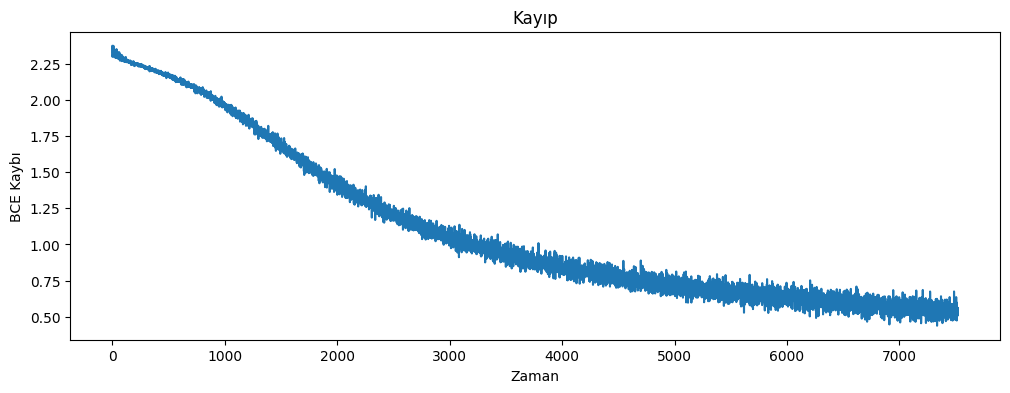

In [28]:
# Eğitim sürecinin kayıp değerlerini görselleştir
plt.figure(figsize=(12, 4))

# Grafik başlığı
plt.title("Kayıp")

# Kayıp değerlerini zaman serisine karşı çiz
# losses: Her batch için kayıp değerleri listesi
plt.plot(losses)

# X ekseni etiketi (batch sayısı/zaman)
plt.xlabel("Zaman")

# Y ekseni etiketi (Cross Entropy Loss değeri)
plt.ylabel("BCE Kaybı")

# Grafiği göster
plt.show()

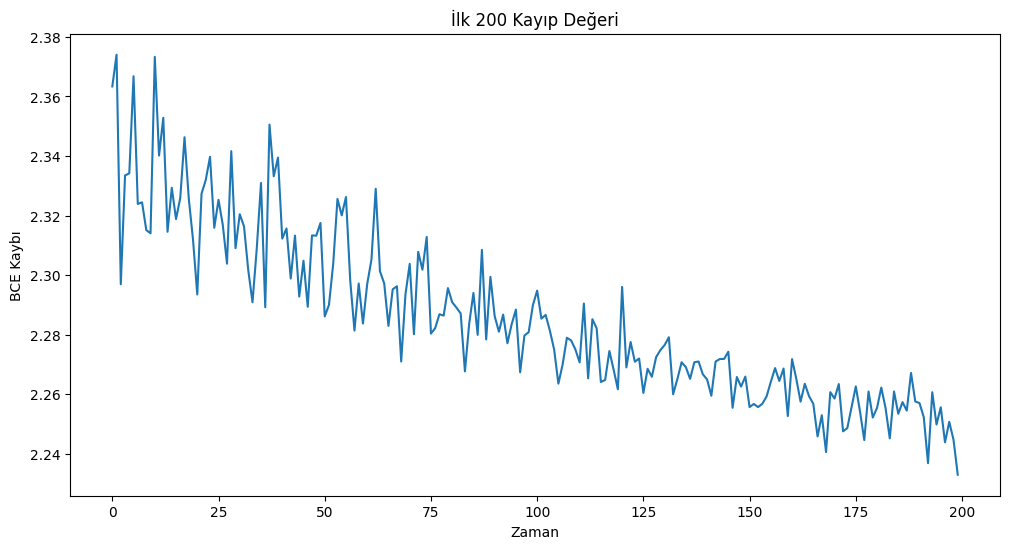

In [29]:
# Eğitimin başlangıcındaki kayıp değerlerini yakından incele
first_n = 200  # İlk 200 kayıp değeri

plt.figure(figsize=(12, 6))

# Grafik başlığı - dinamik olarak first_n değerini göster
plt.title(f"İlk {first_n} Kayıp Değeri")

# losses listesinin ilk 200 değerini çiz
# [:first_n]: Liste dilimlemesi - indeks 0'dan first_n'ye kadar
plt.plot(losses[:first_n])

# Eksen etiketleri
plt.xlabel("Zaman")
plt.ylabel("BCE Kaybı")

# Grafiği göster
plt.show()

## Test Seti ile Modelin Başarısını Hesaplama

In [30]:
# Test veri seti üzerinde model performansını değerlendir

# Gradyan hesaplamasını devre dışı bırak (değerlendirme modu)
# Bu, hafıza kullanımını azaltır ve hesaplamaları hızlandırır
with torch.no_grad():
    # Test verilerini PyTorch tensörüne dönüştür
    # from_numpy(): NumPy dizisini PyTorch tensörüne dönüştür
    # astype(np.float32): Veri tipini 32-bit float'a çevir
    test_tensor = torch.from_numpy(X_test.astype(np.float32))
    
    # Model ile test verisi üzerinde tahmin yap
    # y_predictions: Her örnek için 10 sınıfa ait logit değerleri
    y_predictions = model(test_tensor)

# İlk 3 örneğin logit değerlerini göster
# Her satır bir örnek, her sütun bir sınıf (0-9) skorunu temsil eder
print(y_predictions[:3])

tensor([[-0.6480, -1.1982, -2.3467,  0.7778,  0.5636,  0.5887, -2.9231,  4.2266,
         -0.4980,  2.2022],
        [-0.1650, -0.4562, -0.1322,  5.2082, -2.6486,  2.3210, -1.7482, -1.6114,
          1.1227, -1.5553],
        [-1.4140, -0.2708, -1.0353,  1.2788, -1.1164,  2.0648, -2.6348, -0.9578,
          3.9137,  0.4731]])


## Logitlerden Sınıf Tahminlerine Dönüştürme

In [31]:
# Logit değerlerini sınıf tahminlerine dönüştür

# torch.argmax(): En yüksek değere sahip indeksi bulur
# dim=1: Her satır (örnek) için sütunlar (sınıflar) arasında maksimum bulur
# Sonuç: Her örnek için en olası sınıfın indeksi (0-9 arası)
y_predicted_classes = torch.argmax(y_predictions, dim=1)

# Örnek:
# y_predictions[0] = [0.1, 0.05, 0.8, 0.02, ...] -> argmax = 2 (indeks 2'de maksimum)
# Bu, modelin ilk örneği "2" rakamı olarak sınıflandırdığı anlamına gelir

In [32]:
# İlk 3 sınıf tahminini kontrol et
# Bu değerler 0-9 arası tamsayılar olmalı (MNIST sınıfları)
y_predicted_classes[:3]

tensor([7, 3, 8])

In [33]:
# Gerçek test etiketlerinin ilk 3 değerini kontrol et
# Model tahminleriyle karşılaştırmak için
y_test[:3]

array([7, 3, 8], dtype=uint8)

In [34]:
# Model performansını accuracy metrifi ile hesapla

# accuracy_score(): Doğru tahmin edilen örneklerin toplam örnek sayısına oranı
# y_test: Gerçek etiketler (NumPy dizisi)
# y_predicted_classes: Model tahminleri (PyTorch tensörü - otomatik NumPy'a dönüştürülür)
# Formül: Accuracy = (Doğru Tahminler) / (Toplam Tahminler)
acc = accuracy_score(y_test, y_predicted_classes)

# Accuracy değerini yazdır
# 0.0-1.0 arası değer, 1.0 = %100 doğruluk
print(acc)

0.8739166666666667
